In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

/home/diego/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [45]:
df = pd.read_csv("../data/clean/day_21_cleanest.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  62 non-null     datetime64[ns]
 1   evento     62 non-null     object        
dtypes: datetime64[ns](1), object(1)
memory usage: 1.1+ KB


/tmp/ipykernel_15110/2118990039.py:5: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe()


,timestamp,evento
count,62,62
unique,62,2
top,2025-11-30 08:02:26,entrada
freq,1,32
first,2025-11-30 08:02:26,NaN
last,2025-11-30 20:55:47,NaN


Grafico diario De entradas

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hora"] = df["timestamp"].dt.hour

df_entradas = df[df["evento"] == "entrada"]

plt.figure(figsize=(5,12))

conteo = (
    df_entradas
    .groupby("hora")
    .size()
    .reindex(range(5,22), fill_value=0)
)

plt.figure(figsize=(9,5))

plt.plot(
    conteo.index,
    conteo.values,
    marker="o",
    linestyle="-",
    color="orange",
    label="Entradas"
)


plt.xlabel("Hora del día")
plt.ylabel("Cantidad de entradas")
plt.title("Sun. Nov 30") #Cambiar <----------------
plt.xticks(range(5,22))
plt.grid(True)

plt.ylim(0, 14)
plt.yticks(range(0, 15, 1))

total_entradas = conteo.sum()

plt.text(
    0.98, 0.95,
    f"Entradas: {total_entradas}",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

plt.savefig("../graph_daily/enters/21", dpi=300, bbox_inches="tight") #Cambiar <----------------
plt.show()


Grafico diario de salidas

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hora"] = df["timestamp"].dt.hour

df_salidas = df[df["evento"] == "salida"]

plt.figure(figsize=(5,12))

conteo = (
    df_salidas
    .groupby("hora")
    .size()
    .reindex(range(5,22), fill_value=0)
)

plt.figure(figsize=(9,5))

plt.plot(
    conteo.index,
    conteo.values,
    marker="o",
    linestyle="-",
    color="blue",
    label="Salidas"
)


plt.xlabel("Hora del día")
plt.ylabel("Cantidad de salidas")
plt.title("Sun. Nov 30") #Cambiar <----------------
plt.xticks(range(5,22))
plt.grid(True)

plt.ylim(0, 14)
plt.yticks(range(0, 15, 1))

total_salidas = conteo.sum()

plt.text(
    0.98, 0.95,
    f"Salidas: {total_salidas}",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

plt.savefig("../graph_daily/exits/21", dpi=300, bbox_inches="tight") #Cambiar <----------------
plt.show()


Grafico mediana

In [2]:
data_ent_week = {
    6:  [4, 0, 2, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
    7:  [0, 2, 1, 0, 3, 2, 2, 1, 0, 1, 1, 0, 0, 1, 0],
    8:  [0, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 4, 1, 2, 2],
    9:  [2, 2, 0, 0, 2, 4, 1, 1, 1, 2, 0, 1, 2, 2, 2],
    10: [2, 1, 0, 3, 3, 1, 0, 3, 1, 0, 3, 0, 1, 4, 2],
    11: [4, 3, 1, 1, 3, 3, 1, 4, 5, 3, 2, 2, 5, 4, 2],
    12: [1, 6, 4, 2, 3, 5, 7, 3, 3, 8, 8, 5, 7, 3, 8],
    13: [3, 2, 1, 6, 5, 4, 5, 2, 2, 3, 4, 2, 4, 2, 3],
    14: [6, 6, 3, 2, 2, 4, 5, 6, 5, 1, 5, 2, 4, 4, 2],
    15: [3, 3, 4, 5, 6, 4, 3, 7, 5, 3, 2, 5, 9, 5, 3],
    16: [2, 9, 3, 1, 3, 8, 2, 5, 4, 5, 1, 4, 3, 9, 11],
    17: [5, 6, 4, 7, 6, 4, 5, 10, 4, 7, 8, 4, 5, 3, 2],
    18: [3, 11, 8, 8, 5, 10, 6, 10, 13, 6, 10, 5, 7, 7, 6],
    19: [10, 7, 6, 6, 5, 6, 2, 4, 1, 6, 6, 7, 2, 5, 1],
    20: [3, 5, 4, 4, 5, 6, 5, 8, 3, 5, 7, 5, 10, 1, 7]
}

# Convertir a matriz (filas = horas, columnas = posiciones)
M = np.array(list(data_ent_week .values()))

# Media por columna
media = M.mean(axis=0)

<Figure size 640x480 with 0 Axes>

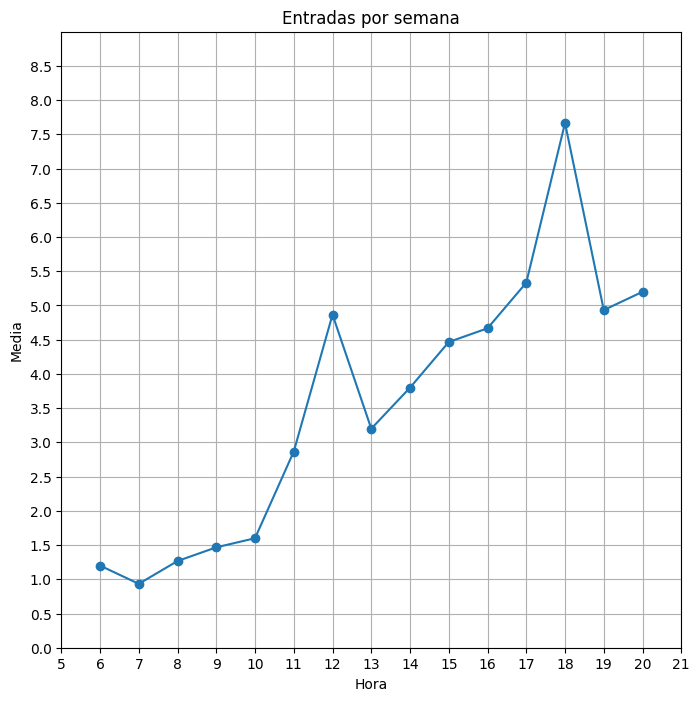

In [ ]:
media_por_hora = M.mean(axis=1)

plt.figure()
plt.figure(figsize=(8,8))
plt.plot(list(data_ent_week.keys()), media_por_hora, marker='o')
plt.title("Media de entradas por semana")
plt.xlabel("Hora")
plt.ylabel("Entradas")
plt.xticks(range(5,22))
plt.grid(True)

plt.ylim(0, 9)
plt.yticks(np.arange(0, 9, .5))

plt.show()